In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
results = pd.read_csv(f"numerical results/UK10ww1.csv")
print(results.to_string())

     id       method        time         cost       penalty
0     2  soft WDRMPC  138.097085   511.108918  0.000000e+00
1     2          mpc   56.231414   545.855602  1.597654e+02
2     2     scenario  149.352543   546.965222  1.632811e+02
3     2      perfect    1.378322   235.259781  0.000000e+00
4     3  soft WDRMPC  137.365352   875.788700  0.000000e+00
5     3          mpc   56.162625   948.234537  1.897939e+02
6     3     scenario  149.230333   947.436881  1.891127e+02
7     3      perfect    1.379776   517.984630  0.000000e+00
8     4  soft WDRMPC  137.640658  1044.396825  0.000000e+00
9     4          mpc   56.287679  1158.285171  2.128586e+02
10    4     scenario  149.281195  1157.272641  2.119158e+02
11    4      perfect    1.382516   726.742400  0.000000e+00
12    5  soft WDRMPC  137.309915   980.734606  0.000000e+00
13    5          mpc   56.190151  1117.643376  2.594155e+02
14    5     scenario  149.125316  1120.348571  2.648989e+02
15    5      perfect    1.417744   682.4

In [3]:
robust_results = pd.read_csv(f"numerical results/UKRobust.csv")
robust_results

,id,method,time,cost,penalty
0,2,robust,59.003596,496.033065,0
1,3,robust,55.420106,885.110813,0
2,4,robust,56.542609,1093.660117,0
3,5,robust,57.054719,1061.964967,0
4,6,robust,55.653125,1101.464732,0
5,7,robust,56.821364,1072.951880,0
6,8,robust,54.423463,969.481959,0
7,9,robust,55.014503,1076.466509,0
8,10,robust,54.242626,1172.471237,0
9,11,robust,54.504005,1113.580838,0


In [4]:
results = pd.merge(results, robust_results, how='outer')
results

/var/folders/0r/xrsnrkm50550l10wsrzlm0m00000gn/T/ipykernel_9956/105511432.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  results = pd.merge(results, robust_results, how='outer')


,id,method,time,cost,penalty
0,2,mpc,56.231414,545.855602,159.765377
1,2,perfect,1.378322,235.259781,0.000000
2,2,robust,59.003596,496.033065,0.000000
3,2,scenario,149.352543,546.965222,163.281092
4,2,soft WDRMPC,138.097085,511.108918,0.000000
...,...,...,...,...,...
145,31,mpc,54.808865,1286.383866,187.675780
146,31,perfect,1.350151,989.234991,0.000000
147,31,robust,52.055646,1225.082875,0.000000
148,31,scenario,146.375663,1288.757789,188.729680


In [19]:
perfect_time = results[results['method'] == 'perfect']['time'].mean() / 96
robust_time = results[results['method'] == 'robust']['time'].mean() / 96
soft_time = results[results['method'] == 'soft WDRMPC']['time'].mean() / 96
mpc_time = results[results['method'] == 'mpc']['time'].mean() / 96
scenario_time = results[results['method'] == 'scenario']['time'].mean() / 96
print(f"Ground truth: {perfect_time}")
print(f"Robust: {robust_time}")
print(f"Soft-WDRMPC: {soft_time}")
print(f"MPC: {mpc_time}")
print(f"Scenario MPC: {scenario_time}")

Ground truth: 0.014362913618485134
Robust: 0.573741355455584
Soft-WDRMPC: 1.413398377266195
MPC: 0.5785219786895646
Scenario MPC: 1.5386238826645746


In [5]:
perfect_cost = results[results['method'] == 'perfect']['cost'].mean()
robust_cost = results[results['method'] == 'robust']['cost'].mean()
soft_cost = results[results['method'] == 'soft WDRMPC']['cost'].mean()
mpc_cost = results[results['method'] == 'mpc']['cost'].mean()
scenario_cost = results[results['method'] == 'scenario']['cost'].mean()
print(f"Ground truth: {perfect_cost}")
print(f"Robust: {robust_cost}")
print(f"Soft-WDRMPC: {soft_cost}")
print(f"MPC: {mpc_cost}")
print(f"Scenario MPC: {scenario_cost}")
robust_gap = (robust_cost - perfect_cost) / perfect_cost * 100
soft_gap = (soft_cost - perfect_cost) / perfect_cost * 100
mpc_gap = (mpc_cost - perfect_cost) / perfect_cost * 100
scenario_gap = (scenario_cost - perfect_cost) / perfect_cost * 100
print(f"Robust Optimality Gap: {robust_gap}")
print(f"Soft Proposed Optimality Gap: {soft_gap}")
print(f"MPC Optimality Gap: {mpc_gap}")
print(f"Scenario MPC Gap: {scenario_gap}")

Ground truth: 697.8832056430347
Robust: 1037.1231570445134
Soft-WDRMPC: 985.9605099121103
MPC: 1096.8613984648339
Scenario MPC: 1096.497560521259
Robust Optimality Gap: 48.60984598259541
Soft Proposed Optimality Gap: 41.27872714799593
MPC Optimality Gap: 57.16976559912741
Scenario MPC Gap: 57.117631095727276


In [7]:
soft_cost = results[results['method'] == 'soft WDRMPC']['cost'].to_numpy()
mpc_cost = results[results['method'] == 'mpc']['cost'].to_numpy()
scenario_cost = results[results['method'] == 'scenario']['cost'].to_numpy()
perfect_cost = results[results['method'] == 'perfect']['cost'].to_numpy()
robust_cost = results[results['method'] == 'robust']['cost'].to_numpy()
soft_gap = (soft_cost - perfect_cost) / perfect_cost * 100 
dmpc_gap = (mpc_cost - perfect_cost) / perfect_cost * 100
smpc_gap = (scenario_cost - perfect_cost) / perfect_cost * 100
rmpc_gap = (robust_cost - perfect_cost) / perfect_cost * 100
rmpc_std = np.std(rmpc_gap)
soft_std = np.std(soft_gap)
dmpc_std = np.std(dmpc_gap)
smpc_std = np.std(smpc_gap)
print(f"Soft Proposed Std: {soft_std}")
print(f"RMPC Std: {rmpc_std}")
print(f"DMPC Std: {dmpc_std}")
print(f"SMPC Std: {smpc_std}")

Soft Proposed Std: 26.935910825685294
RMPC Std: 25.263238020204902
DMPC Std: 28.839630199630644
SMPC Std: 28.695699266087164


In [8]:
perfect_penalty = results[results['method'] == 'perfect']['penalty'].mean()
robust_penalty = results[results['method'] == 'robust']['penalty'].mean()
soft_penalty = results[results['method'] == 'soft WDRMPC']['penalty'].mean()
mpc_penalty = results[results['method'] == 'mpc']['penalty'].mean()
scenario_penalty = results[results['method'] == 'scenario']['penalty'].mean()
print(f"Ground truth penalty: {perfect_penalty}")
print(f"Soft-WDRMPC penalty: {soft_penalty}")
print(f"MPC penalty: {mpc_penalty}")
print(f"Robust MPC penalty: {robust_penalty}")
print(f"Scenario MPC penalty: {scenario_penalty}")
print(f"Proposed Soft Operational Cost: {soft_cost.mean() - soft_penalty}")
print(f"MPC Operational Cost: {mpc_cost.mean() - mpc_penalty}")
print(f"RMPC Operational Cost: {robust_cost.mean() - robust_penalty}")
print(f"SMPC Operational Cost: {scenario_cost.mean() - scenario_penalty}")

Ground truth penalty: 3.7210789852726475e-08
Soft-WDRMPC penalty: 0.0
MPC penalty: 228.3208522133373
Robust MPC penalty: 0.0
Scenario MPC penalty: 229.77312396599058
Proposed Soft Operational Cost: 985.9605099121103
MPC Operational Cost: 868.5405462514966
RMPC Operational Cost: 1037.1231570445134
SMPC Operational Cost: 866.7244365552683


/var/folders/0r/xrsnrkm50550l10wsrzlm0m00000gn/T/ipykernel_9956/3441130623.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_methods.rename(columns={'soft WDRMPC': 'DR-TMPC', 'scenario': 'SMPC', 'robust': 'RMPC'}, inplace=True)


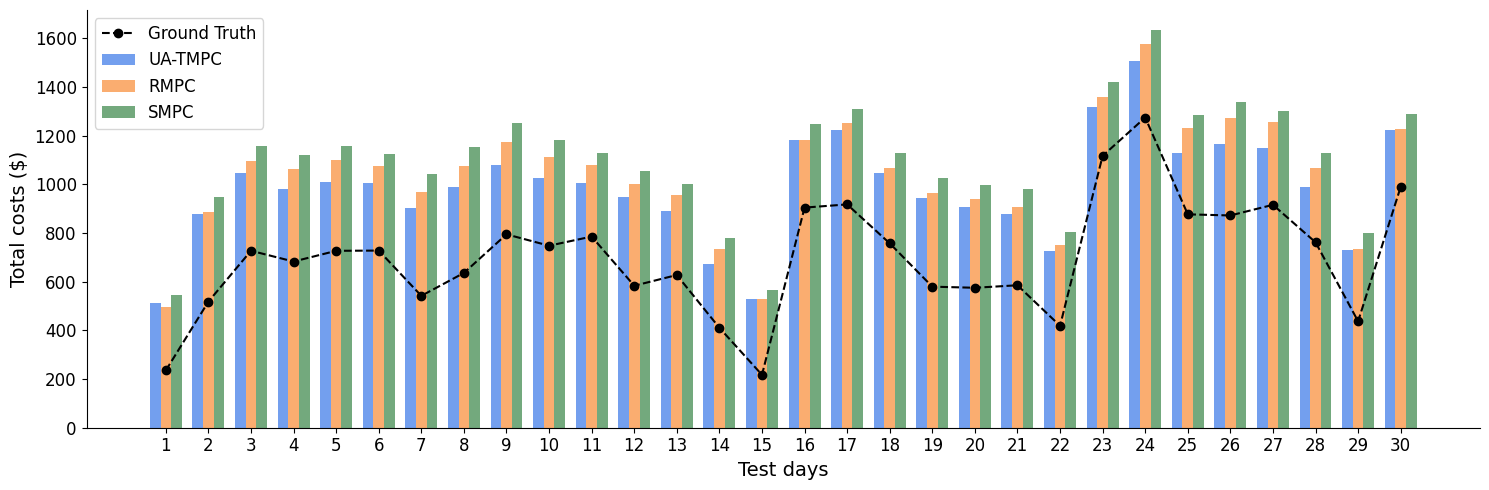

In [11]:
days = np.arange(1, 31)
methods = ['soft WDRMPC', 'robust', 'scenario']
all_methods = methods + ['perfect']
df_gt = results[results['method'] == 'perfect']
df_methods = results[results['method'] != 'perfect']
df_methods.rename(columns={'soft WDRMPC': 'DR-TMPC', 'scenario': 'SMPC', 'robust': 'RMPC'}, inplace=True)
df_pivot = df_methods.pivot(index='id', columns='method', values='cost')
df_pivot = df_pivot[methods]

fig, ax = plt.subplots(figsize=(15, 5))
num_methods = len(methods)
bar_width = 0.25
# days_x = df_pivot.index.values
days_x = days
colors = ['#6495ED', '#FAA460', '#64A06F']
labels = ['UA-TMPC', 'RMPC', 'SMPC',]
for i, method in enumerate(methods):
    position = days_x + (i - (num_methods - 1) / 2) * bar_width
    ax.bar(position, df_pivot[method], width=bar_width, label=labels[i], color=colors[i], alpha=0.9)

# 绘制 Ground-truth 折线图
ax.plot(days, df_gt['cost'],
        label='Ground Truth',
        color='black',
        linestyle='--',
        marker='o')
# --- 图形美化 ---
ax.set_xlabel('Test days', fontsize=14)
ax.set_ylabel('Total costs ($)', fontsize=14)
ax.set_xticks(days_x) # 设置 X 轴刻度为 1 到 30
ax.set_xticklabels(days_x.astype(int))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.set_ylim(0)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"figures/Comparison plots.pdf", bbox_inches='tight')
plt.show()

/var/folders/0r/xrsnrkm50550l10wsrzlm0m00000gn/T/ipykernel_9956/2936104857.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_methods.rename(columns={'soft WDRMPC': 'DR-TMPC', 'scenario': 'SMPC', 'robust': 'RMPC', 'mpc': 'DMPC'}, inplace=True)


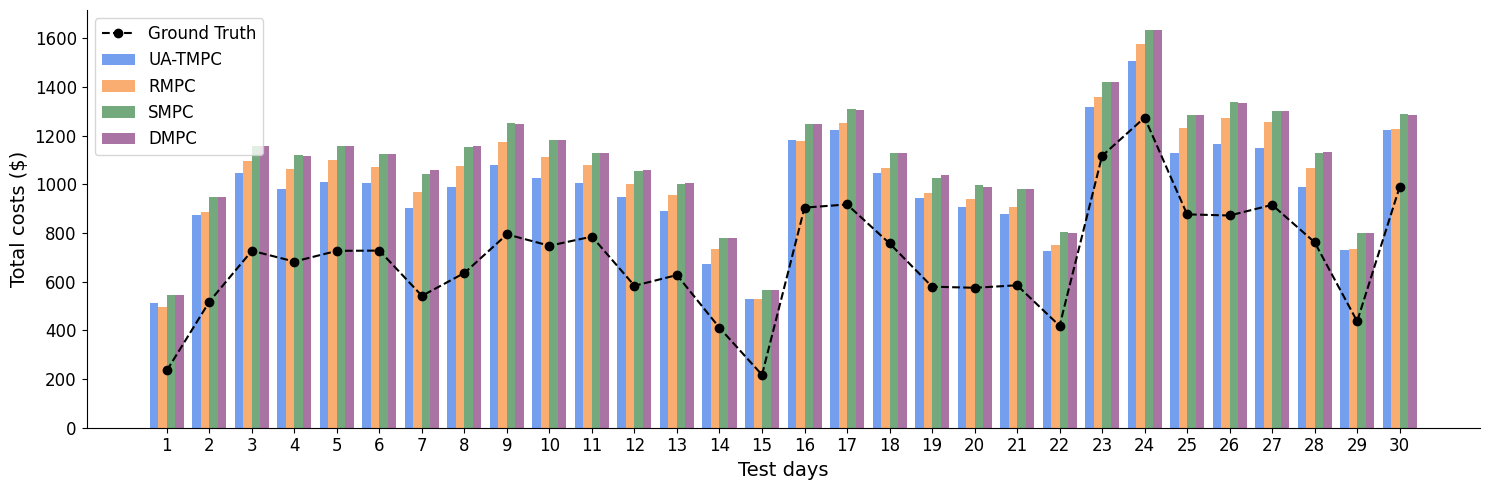

In [17]:
days = np.arange(1, 31)
methods = ['soft WDRMPC', 'robust', 'scenario', 'mpc']
all_methods = methods + ['perfect']
df_gt = results[results['method'] == 'perfect']
df_methods = results[results['method'] != 'perfect']
df_methods.rename(columns={'soft WDRMPC': 'DR-TMPC', 'scenario': 'SMPC', 'robust': 'RMPC', 'mpc': 'DMPC'}, inplace=True)
df_pivot = df_methods.pivot(index='id', columns='method', values='cost')
df_pivot = df_pivot[methods]

fig, ax = plt.subplots(figsize=(15, 5))
num_methods = len(methods)
bar_width = 0.2
# days_x = df_pivot.index.values
days_x = days
colors = ['#6495ED', '#FAA460', '#64A06F', "#A0649A"]
labels = ['UA-TMPC', 'RMPC', 'SMPC', 'DMPC']
for i, method in enumerate(methods):
    position = days_x + (i - (num_methods - 1) / 2) * bar_width
    ax.bar(position, df_pivot[method], width=bar_width, label=labels[i], color=colors[i], alpha=0.9)

# 绘制 Ground-truth 折线图
ax.plot(days, df_gt['cost'],
        label='Ground Truth',
        color='black',
        linestyle='--',
        marker='o')
# --- 图形美化 ---
ax.set_xlabel('Test days', fontsize=14)
ax.set_ylabel('Total costs ($)', fontsize=14)
ax.set_xticks(days_x) # 设置 X 轴刻度为 1 到 30
ax.set_xticklabels(days_x.astype(int))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.set_ylim(0)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"figures/Comparison plots 4 methods.pdf", bbox_inches='tight')
plt.show()